# Random Forest Model for Delinquency Prediction

Uses the **top N selected features** from `filtered_features_consensus_ordered.csv`.

- Train / Validation / Test split (60/20/20, stratified)
- Three training variants compared side-by-side:
  - **Original** — weighted via `class_weight='balanced'`
  - **SMOTE** — Synthetic Minority Over-sampling Technique
  - **ADASYN** — Adaptive Synthetic Sampling
- Metrics: ROC-AUC, Average Precision, training time

In [1]:
import sys
import pathlib
import importlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE, ADASYN

import scripts.model_data as _md
importlib.reload(_md)
from scripts.model_data import load_and_split

## 1. Load Data & Selected Features

In [2]:
# ── Configuration ────────────────────────────────────────────────
N_FEATURES    = 50
FEATURES_FILE = "filtered_features_consensus_ordered.csv"

X_train, X_val, X_test, y_train, y_val, y_test, feature_names, features_df = \
    load_and_split(n_features=N_FEATURES, features_filename=FEATURES_FILE)

print(f'Features used : {len(feature_names)}')
print(f'Train         : {X_train.shape}  | positives: {y_train.sum()} ({100*y_train.mean():.1f}%)')
print(f'Validation    : {X_val.shape}  | positives: {y_val.sum()} ({100*y_val.mean():.1f}%)')
print(f'Test          : {X_test.shape}  | positives: {y_test.sum()} ({100*y_test.mean():.1f}%)')

Features  : 50 (top-50)
Samples   : 9277  |  DQ rate: 8.70%
Train     : 5566  (8.70% positive)
Val       : 1855  (8.68% positive)
Test      : 1856  (8.73% positive)
Features used : 50
Train         : (5566, 50)  | positives: 484 (8.7%)
Validation    : (1855, 50)  | positives: 161 (8.7%)
Test          : (1856, 50)  | positives: 162 (8.7%)


## 2. Helper: Evaluate Model

In [3]:
def evaluate(model, X, y_true, split_name, threshold=0.5):
    """Score a fitted sklearn model and print key metrics."""
    t0 = time.time()
    y_proba = model.predict_proba(X)[:, 1]
    scoring_time = time.time() - t0

    auc = roc_auc_score(y_true, y_proba)
    ap  = average_precision_score(y_true, y_proba)
    y_pred = (y_proba >= threshold).astype(int)

    print(f'\n{"="*55}')
    print(f'{split_name}')
    print(f'{"="*55}')
    print(f'ROC-AUC          : {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print(f'Scoring time     : {scoring_time:.4f}s')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['No DQ', 'DQ']))
    print(f'Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))

    return y_proba, auc, ap, scoring_time

---
## 3. Original — `class_weight='balanced'`

No oversampling; the forest compensates by weighting each class inversely to its frequency.

In [4]:
print('Training Random Forest (original, class_weight=balanced)...')
t0 = time.time()

rf_orig = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf_orig.fit(X_train, y_train)
train_time_orig = time.time() - t0
print(f'Training completed in {train_time_orig:.2f}s')

Training Random Forest (original, class_weight=balanced)...
Training completed in 0.66s


In [5]:
_, train_auc_orig, train_ap_orig, _ = evaluate(rf_orig, X_train, y_train, 'TRAIN (original)')
_, val_auc_orig,   val_ap_orig,   _ = evaluate(rf_orig, X_val,   y_val,   'VALIDATION (original)')
_, test_auc_orig,  test_ap_orig,  _ = evaluate(rf_orig, X_test,  y_test,  'TEST (original)')


TRAIN (original)
ROC-AUC          : 0.9996
Average Precision: 0.9943
Scoring time     : 0.0932s

Classification Report:
              precision    recall  f1-score   support

       No DQ       1.00      1.00      1.00      5082
          DQ       0.97      1.00      0.98       484

    accuracy                           1.00      5566
   macro avg       0.98      1.00      0.99      5566
weighted avg       1.00      1.00      1.00      5566

Confusion Matrix:
[[5065   17]
 [   1  483]]

VALIDATION (original)
ROC-AUC          : 0.7978
Average Precision: 0.3120
Scoring time     : 0.0883s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.92      0.98      0.95      1694
          DQ       0.44      0.16      0.23       161

    accuracy                           0.91      1855
   macro avg       0.68      0.57      0.59      1855
weighted avg       0.88      0.91      0.89      1855

Confusion Matrix:
[[1662   32]
 [ 136   25]]

TEST (or

---
## 4. SMOTE — Synthetic Minority Over-sampling

Oversample the minority class on the **training set only**. Val/Test remain untouched.

In [6]:
smote = SMOTE(sampling_strategy='minority', random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE  : {np.bincount(y_train)}')
print(f'After  SMOTE  : {np.bincount(y_train_smote)}')

Before SMOTE  : [5082  484]
After  SMOTE  : [5082 5082]


In [7]:
print('Training Random Forest (SMOTE)...')
t0 = time.time()

rf_smote = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)
rf_smote.fit(X_train_smote, y_train_smote)
train_time_smote = time.time() - t0
print(f'Training completed in {train_time_smote:.2f}s')

Training Random Forest (SMOTE)...
Training completed in 1.22s


In [8]:
# Evaluate on original (non-oversampled) splits
_, train_auc_smote, train_ap_smote, _ = evaluate(rf_smote, X_train, y_train, 'TRAIN (SMOTE)')
_, val_auc_smote,   val_ap_smote,   _ = evaluate(rf_smote, X_val,   y_val,   'VALIDATION (SMOTE)')
_, test_auc_smote,  test_ap_smote,  _ = evaluate(rf_smote, X_test,  y_test,  'TEST (SMOTE)')


TRAIN (SMOTE)
ROC-AUC          : 0.9928
Average Precision: 0.9474
Scoring time     : 0.0925s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.99      0.99      0.99      5082
          DQ       0.91      0.84      0.87       484

    accuracy                           0.98      5566
   macro avg       0.95      0.92      0.93      5566
weighted avg       0.98      0.98      0.98      5566

Confusion Matrix:
[[5040   42]
 [  76  408]]

VALIDATION (SMOTE)
ROC-AUC          : 0.7762
Average Precision: 0.2624
Scoring time     : 0.0676s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.94      0.92      0.93      1694
          DQ       0.29      0.34      0.31       161

    accuracy                           0.87      1855
   macro avg       0.61      0.63      0.62      1855
weighted avg       0.88      0.87      0.88      1855

Confusion Matrix:
[[1564  130]
 [ 107   54]]

TEST (SMOTE)
R

---
## 5. ADASYN — Adaptive Synthetic Sampling

Like SMOTE but generates **more synthetic samples in harder-to-learn regions** of the minority class.

In [9]:
adasyn = ADASYN(sampling_strategy='minority', random_state=42, n_neighbors=5)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

print(f'Before ADASYN : {np.bincount(y_train)}')
print(f'After  ADASYN : {np.bincount(y_train_ada)}')

Before ADASYN : [5082  484]
After  ADASYN : [5082 5137]


In [10]:
print('Training Random Forest (ADASYN)...')
t0 = time.time()

rf_ada = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)
rf_ada.fit(X_train_ada, y_train_ada)
train_time_ada = time.time() - t0
print(f'Training completed in {train_time_ada:.2f}s')

Training Random Forest (ADASYN)...
Training completed in 1.31s


In [11]:
# Evaluate on original (non-oversampled) splits
_, train_auc_ada, train_ap_ada, _ = evaluate(rf_ada, X_train, y_train, 'TRAIN (ADASYN)')
_, val_auc_ada,   val_ap_ada,   _ = evaluate(rf_ada, X_val,   y_val,   'VALIDATION (ADASYN)')
_, test_auc_ada,  test_ap_ada,  _ = evaluate(rf_ada, X_test,  y_test,  'TEST (ADASYN)')


TRAIN (ADASYN)
ROC-AUC          : 0.9928
Average Precision: 0.9482
Scoring time     : 0.1122s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.99      0.99      0.99      5082
          DQ       0.87      0.87      0.87       484

    accuracy                           0.98      5566
   macro avg       0.93      0.93      0.93      5566
weighted avg       0.98      0.98      0.98      5566

Confusion Matrix:
[[5020   62]
 [  63  421]]

VALIDATION (ADASYN)
ROC-AUC          : 0.7814
Average Precision: 0.2553
Scoring time     : 0.0761s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.93      0.92      0.93      1694
          DQ       0.28      0.32      0.30       161

    accuracy                           0.87      1855
   macro avg       0.61      0.62      0.61      1855
weighted avg       0.88      0.87      0.87      1855

Confusion Matrix:
[[1565  129]
 [ 110   51]]

TEST (ADASYN

---
## 6. Comparison — Original vs SMOTE vs ADASYN

In [12]:
print('Random Forest – Original vs SMOTE vs ADASYN')
print(f'  Features: {len(feature_names)}  |  Feature file: {FEATURES_FILE}')
print('=' * 72)
print(f'{"Split":<10} {"Metric":<20} {"Original (balanced)":<22} {"SMOTE":<12} {"ADASYN":<12}')
print('-' * 72)

for split_name, auc_o, ap_o, auc_s, ap_s, auc_a, ap_a in [
    ('Train', train_auc_orig, train_ap_orig, train_auc_smote, train_ap_smote, train_auc_ada, train_ap_ada),
    ('Val',   val_auc_orig,   val_ap_orig,   val_auc_smote,   val_ap_smote,   val_auc_ada,   val_ap_ada),
    ('Test',  test_auc_orig,  test_ap_orig,  test_auc_smote,  test_ap_smote,  test_auc_ada,  test_ap_ada),
]:
    print(f'{split_name:<10} {"ROC-AUC":<20} {auc_o:<22.4f} {auc_s:<12.4f} {auc_a:<12.4f}')
    print(f'{"":<10} {"Avg Precision":<20} {ap_o:<22.4f} {ap_s:<12.4f} {ap_a:<12.4f}')

print('=' * 72)
print(f'{"Training time":<10} {"":<20} {train_time_orig:<22.2f} {train_time_smote:<12.2f} {train_time_ada:<12.2f}')

Random Forest – Original vs SMOTE vs ADASYN
  Features: 50  |  Feature file: filtered_features_consensus_ordered.csv
Split      Metric               Original (balanced)    SMOTE        ADASYN      
------------------------------------------------------------------------
Train      ROC-AUC              0.9996                 0.9928       0.9928      
           Avg Precision        0.9943                 0.9474       0.9482      
Val        ROC-AUC              0.7978                 0.7762       0.7814      
           Avg Precision        0.3120                 0.2624       0.2553      
Test       ROC-AUC              0.8397                 0.7892       0.7924      
           Avg Precision        0.3653                 0.2342       0.2353      
Training time                      0.66                   1.22         1.31        


## 7. Feature Importance (Best Model)

Best model by val AUC: Original (balanced)


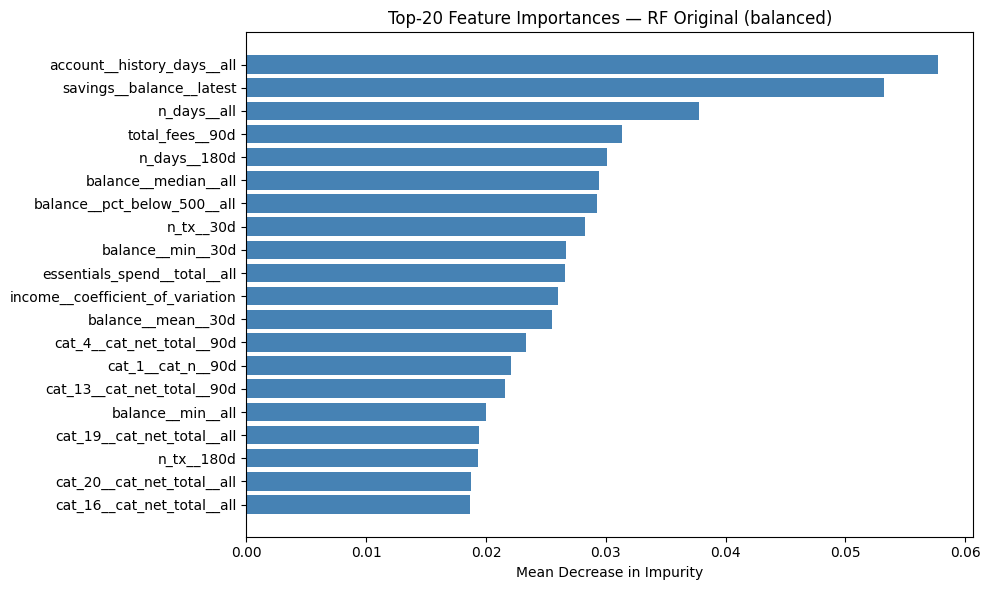

In [13]:
# Pick the model with the best validation AUC
best_label, best_model = max(
    [('Original (balanced)', rf_orig, val_auc_orig),
     ('SMOTE',               rf_smote, val_auc_smote),
     ('ADASYN',              rf_ada,   val_auc_ada)],
    key=lambda x: x[2],
)[:2]

print(f'Best model by val AUC: {best_label}')

TOP_N = 20
importances = best_model.feature_importances_
indices     = np.argsort(importances)[::-1][:TOP_N]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    y=np.array(feature_names)[indices][::-1],
    width=importances[indices][::-1],
    color='steelblue',
)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title(f'Top-{TOP_N} Feature Importances — RF {best_label}')
plt.tight_layout()
plt.show()